In [6]:
##https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [9]:
#df = pd.read_csv("Mall_Customers.csv")
#df.head()

In [10]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]].values
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

z = linkage(x_scaler,method="ward")



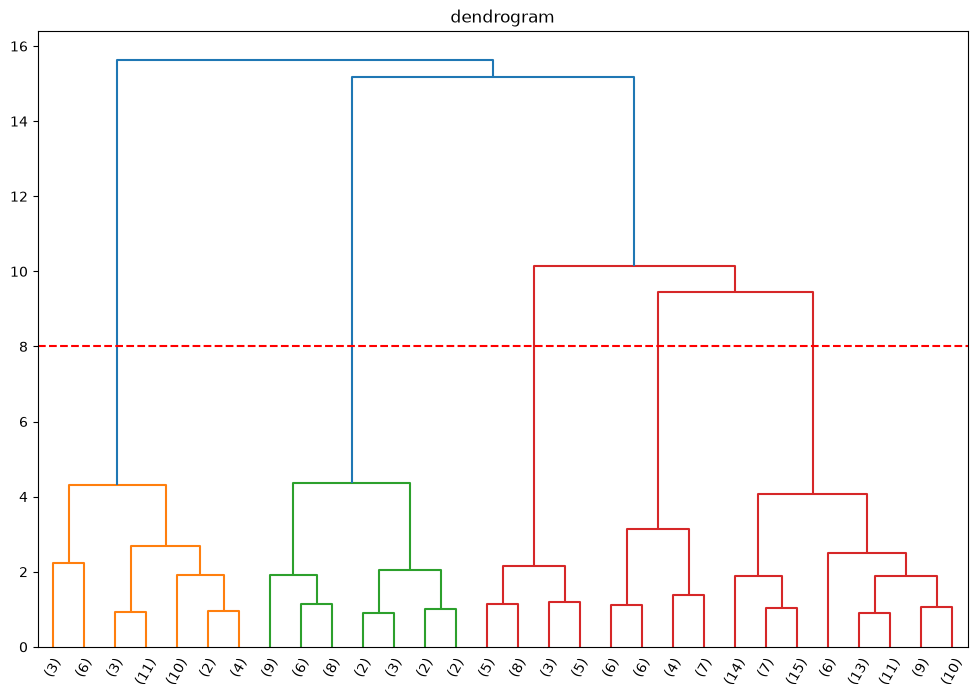

In [11]:
plt.figure(figsize=(12,8))
dendrogram(z,truncate_mode="lastp",p=30,leaf_rotation=60)
plt.title("dendrogram")
plt.axhline(y=8,color="r",linestyle="--")
plt.show()

0      4
1      3
2      4
3      3
4      4
      ..
195    1
196    0
197    1
198    0
199    1
Name: cluster, Length: 200, dtype: int64


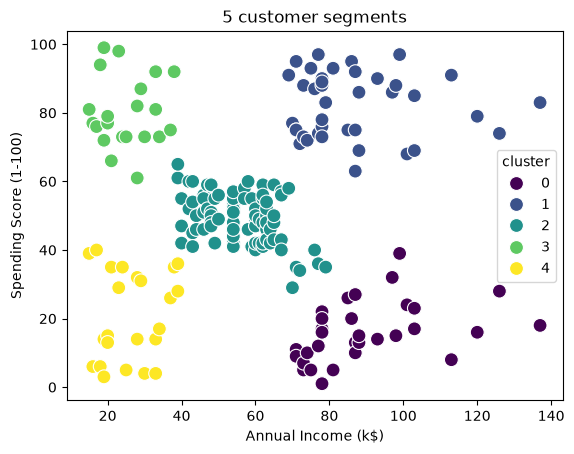

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                                   
0        166.250000  41.000000           89.406250               15.593750
1        162.000000  32.692308           86.538462               82.128205
2         87.894118  42.482353           55.811765               49.129412
3         22.000000  25.333333           25.095238               80.047619
4         23.000000  45.217391           26.304348               20.913043

 silhoutte score  0.5538089226688662


In [12]:
hc = AgglomerativeClustering(n_clusters=5,metric="euclidean",linkage="ward")
df["cluster"] = hc.fit_predict(x_scaler)

print(df["cluster"])
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)",
                hue="cluster",palette="viridis",s=100)
plt.title("5 customer segments")
plt.show()

print(df.groupby("cluster").mean(numeric_only=True))
print("\n silhoutte score ",silhouette_score(x_scaler,df["cluster"]))